#SPRINT 1 - İsmail Hakkı Oruç

#Veri Analizi ve Ön İşleme

In [ ]:
# 1. IMPORTS
%matplotlib inline

from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import Counter

import gc
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# 2. SABİTLER
DATASET_ROOT = Path(r"C:\Users\WinOn\Desktop\data\raw\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia")

IMG_SIZE = 224
BATCH_SIZE = 16
VAL_RATIO = 0.2
SEED = 42

NUM_EPOCHS = 5
PATIENCE = 3

torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
# 3. YARDIMCI FONKSİYONLAR
def find_dir_case_insensitive(parent, folder_name):
    parent = Path(parent)

    if not parent.exists():
        raise FileNotFoundError(f"Klasör bulunamadı: {parent}")

    for p in parent.iterdir():
        if p.is_dir() and p.name.lower() == folder_name.lower():
            return p

    raise FileNotFoundError(f"{parent} içinde '{folder_name}' klasörü bulunamadı.")


def list_images(folder):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    return sorted([
        p for p in Path(folder).rglob("*")
        if p.suffix.lower() in valid_exts
    ])


def check_image_file(img_path):
    try:
        with Image.open(img_path) as img:
            img.verify()
        return True, None
    except (UnidentifiedImageError, OSError, IOError) as e:
        return False, str(e)


def show_images(image_paths, title, n=6):
    n = min(n, len(image_paths))

    plt.figure(figsize=(12, 6))

    for i in range(n):
        img = Image.open(image_paths[i]).convert("L")

        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(image_paths[i].name)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# 4. KLASÖRLER
train_dir = find_dir_case_insensitive(DATASET_ROOT, "Training")
test_dir = find_dir_case_insensitive(DATASET_ROOT, "Testing")

train_normal_dir = find_dir_case_insensitive(train_dir, "normal")
train_pneumonia_dir = find_dir_case_insensitive(train_dir, "pneumonia")

test_normal_dir = find_dir_case_insensitive(test_dir, "normal")
test_pneumonia_dir = find_dir_case_insensitive(test_dir, "pneumonia")

In [ ]:
# 5. GÖRÜNTÜLER
train_normal_imgs = list_images(train_normal_dir)
train_pneumonia_imgs = list_images(train_pneumonia_dir)

test_normal_imgs = list_images(test_normal_dir)
test_pneumonia_imgs = list_images(test_pneumonia_dir)

all_images = (
    train_normal_imgs +
    train_pneumonia_imgs +
    test_normal_imgs +
    test_pneumonia_imgs
)

print("Toplam görüntü:", len(all_images))

Toplam görüntü: 3354


In [ ]:
# 6. SINIF DAĞILIMI
print("\n===== SINIF DAĞILIMI =====")
print("Train normal    :", len(train_normal_imgs))
print("Train pneumonia :", len(train_pneumonia_imgs))
print("Test normal     :", len(test_normal_imgs))
print("Test pneumonia  :", len(test_pneumonia_imgs))


===== SINIF DAĞILIMI =====
Train normal    : 1363
Train pneumonia : 1350
Test normal     : 321
Test pneumonia  : 320


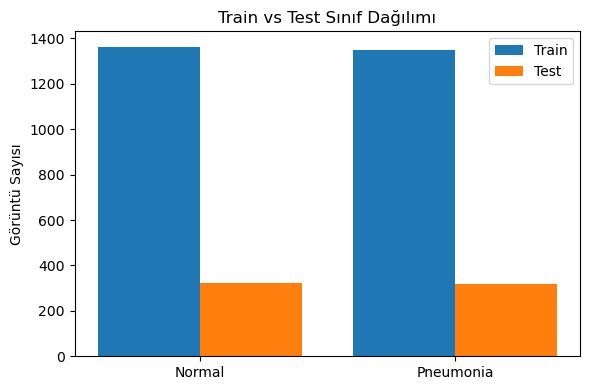

In [ ]:
train_counts = [len(train_normal_imgs), len(train_pneumonia_imgs)]
test_counts = [len(test_normal_imgs), len(test_pneumonia_imgs)]

x = np.arange(2)

plt.figure(figsize=(6, 4))
plt.bar(x, train_counts, width=0.4, label="Train", align="center")
plt.bar(x + 0.4, test_counts, width=0.4, label="Test")
plt.xticks(x + 0.2, ["Normal", "Pneumonia"])
plt.ylabel("Görüntü Sayısı")
plt.title("Train vs Test Sınıf Dağılımı")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 7. BOZUK DOSYA KONTROLÜ
bad_files = []

for img_path in all_images:
    ok, err = check_image_file(img_path)
    if not ok:
        bad_files.append((img_path, err))

print("\n===== BOZUK DOSYA KONTROLÜ =====")
print("Toplam görüntü:", len(all_images))
print("Bozuk dosya sayısı:", len(bad_files))

if len(bad_files) > 0:
    print("İlk birkaç bozuk dosya:")
    for p, e in bad_files[:5]:
        print("-", p, "| Hata:", e)


===== BOZUK DOSYA KONTROLÜ =====
Toplam görüntü: 3354
Bozuk dosya sayısı: 0


In [ ]:
# 8. BOYUT ANALİZİ
records = []

for split_name, label_name, paths in [
    ("train", "normal", train_normal_imgs),
    ("train", "pneumonia", train_pneumonia_imgs),
    ("test", "normal", test_normal_imgs),
    ("test", "pneumonia", test_pneumonia_imgs),
]:
    for p in paths:
        try:
            with Image.open(p) as img:
                w, h = img.size
                mode = img.mode

            records.append({
                "split": split_name,
                "label": label_name,
                "path": str(p),
                "width": w,
                "height": h,
                "mode": mode,
                "ratio": round(w / h, 4) if h != 0 else None
            })
        except:
            pass

df = pd.DataFrame(records)

print("\n===== BOYUT ANALİZİ =====")
print(df[["width", "height"]].describe())

print("\nSınıfa göre boyut özeti:")
print(df.groupby(["split", "label"])[["width", "height"]].agg(["mean", "min", "max"]))

top_sizes = (
    df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

print("\nEn sık görülen ilk 10 boyut:")
print(top_sizes)


===== BOYUT ANALİZİ =====
             width       height
count  3354.000000  3354.000000
mean   1116.492248   913.830054
std     469.676414   387.992685
min     256.000000   151.000000
25%     856.000000   515.500000
50%    1024.000000   964.000000
75%    1442.000000  1072.000000
max    2916.000000  2583.000000

Sınıfa göre boyut özeti:
                       width                  height           
                        mean  min   max         mean  min   max
split label                                                    
test  normal      903.962617  256  2514   850.978193  256  2264
      pneumonia  1369.315625  439  2890  1017.443750  151  2570
train normal      893.088775  256  2553   838.807043  256  2376
      pneumonia  1332.653333  438  2916   979.960000  173  2583

En sık görülen ilk 10 boyut:
      width  height  count
328    1024    1024    669
20      512     512    650
0       256     256     90
388    1072     648      4
1226   1612    1437      3
1290   1662    1276

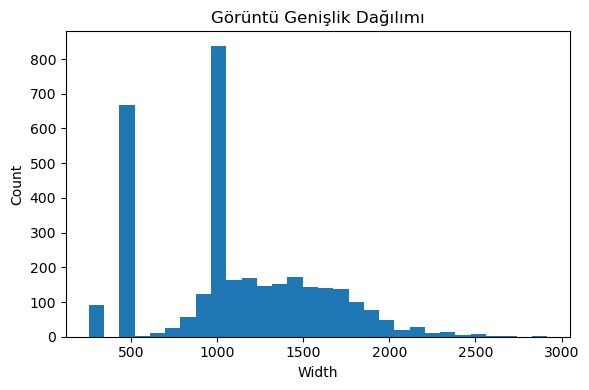

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["width"], bins=30)
plt.xlabel("Width")
plt.ylabel("Count")
plt.title("Görüntü Genişlik Dağılımı")
plt.tight_layout()
plt.show()

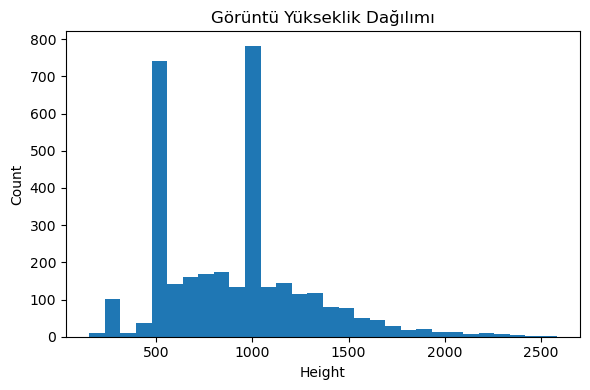

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["height"], bins=30)
plt.xlabel("Height")
plt.ylabel("Count")
plt.title("Görüntü Yükseklik Dağılımı")
plt.tight_layout()
plt.show()

In [ ]:
print("Normal görüntü sayısı:", len(train_normal_imgs))
print("Pneumonia görüntü sayısı:", len(train_pneumonia_imgs))

Normal görüntü sayısı: 1363
Pneumonia görüntü sayısı: 1350



===== ÖRNEK GÖRÜNTÜLER =====


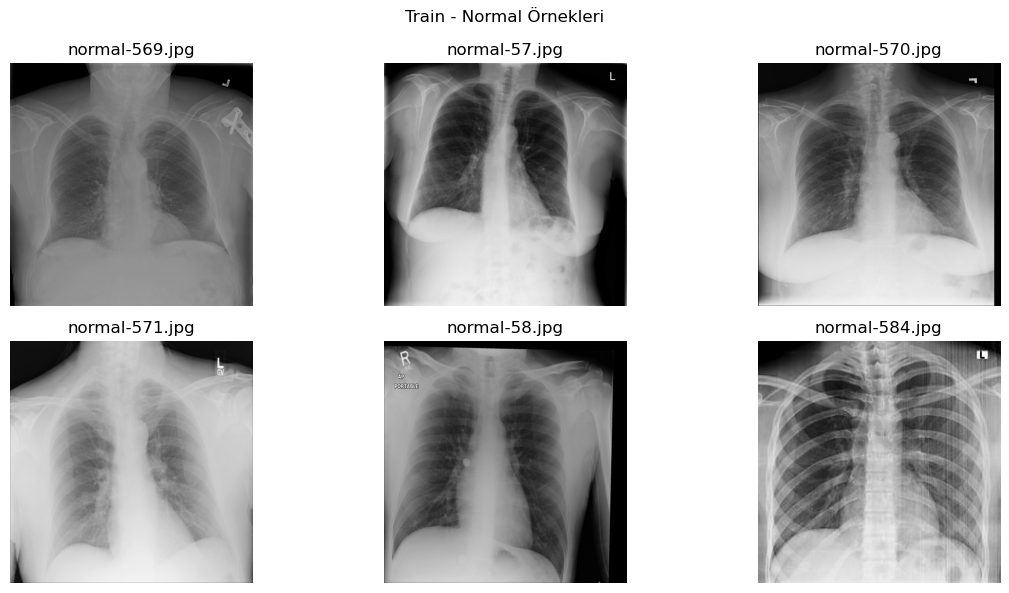

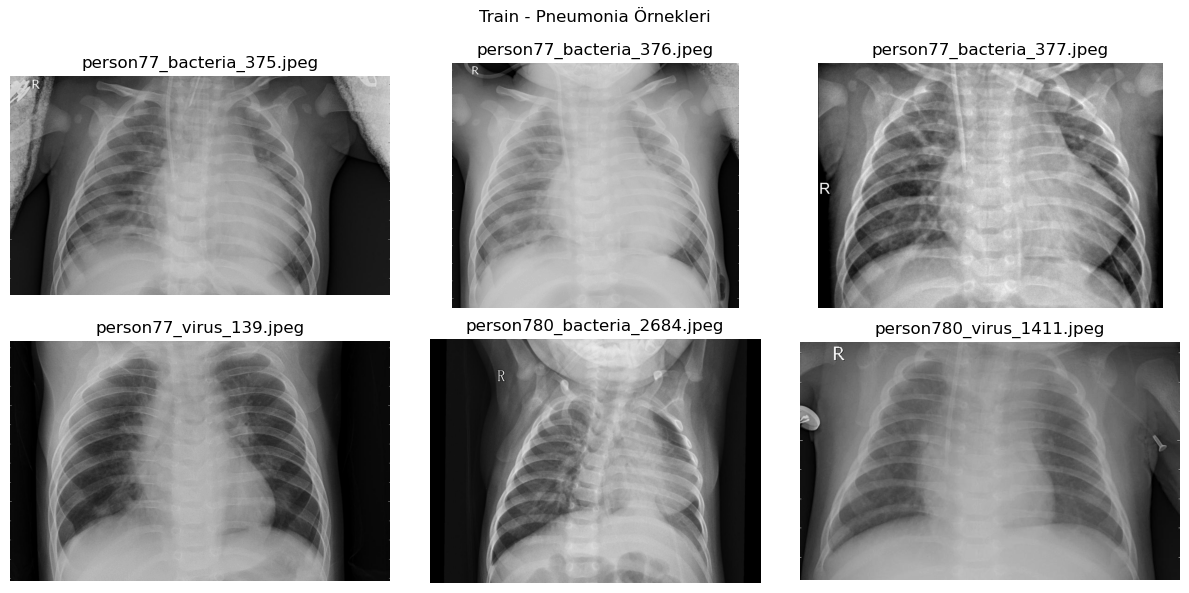

In [ ]:
# 9. ÖRNEK GÖRÜNTÜLER
print("\n===== ÖRNEK GÖRÜNTÜLER =====")
show_images(train_normal_imgs, "Train - Normal Örnekleri", n=6)
show_images(train_pneumonia_imgs, "Train - Pneumonia Örnekleri", n=6)

In [ ]:
# 10. PİKSEL İSTATİSTİĞİ
def compute_mean_std(image_paths, img_size=224, max_images=300):
    vals = []

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

    paths = image_paths if max_images is None else image_paths[:max_images]

    for p in paths:
        try:
            img = Image.open(p).convert("L")
            x = tfm(img)
            vals.append(x)
        except:
            pass

    stacked = torch.stack(vals, dim=0)

    mean = stacked.mean().item()
    std = stacked.std().item()

    return mean, std


mean_value, std_value = compute_mean_std(
    all_images,
    img_size=IMG_SIZE,
    max_images=300
)

print("\n===== PİKSEL İSTATİSTİĞİ =====")
print(f"Hesaplanan mean: {mean_value:.4f}")
print(f"Hesaplanan std : {std_value:.4f}")



===== PİKSEL İSTATİSTİĞİ =====
Hesaplanan mean: 0.5099
Hesaplanan std : 0.2546


#SPRINT 2 - Zeynep Şafak

#Dataset, Model ve Eğitim